# Notebook angle estimation machine learning part
This notebook contains the code that is used to train the model for predicting the best angle at which the angiography should be taken 

In [1]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime
import neptune
import model as mf

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [ ]:
run = neptune.init_run(
     name= "Try 2",
     description= "Experiment with new data",
     project="undefined1234/Team-Challenge",
     api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJlZTZlZjc1Mi00YTFlLTQ1YjUtYjBiNC02OGRkZTY4ZDAwMTgifQ==",
)  # your credentials

params = {

    "learning_rate": 0.001,
    "momentum": 0.9,
    "optimizer": "SGD"
}
run["parameters"] = params

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/undefined1234/Team-Challenge/e/TEAM-4


In [3]:
torch.__version__

'2.6.0+cu126'

In [4]:
torch.cuda.is_available()

True

## Loading labels

In [2]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
labels['score_classified'] = pd.qcut(labels['score'], 5).factorize()[0]

#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath,score_classified
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png,0
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png,1
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png,1
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png,1
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png,2
...,...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png,3
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png,4
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png,4
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png,3


### DataLoader

In [3]:
train, val = train_test_split(labels)

train_dataloader = torch.utils.data.DataLoader(mf.CustomImageDataset(train), batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mf.CustomImageDataset(val), batch_size=64, shuffle=True)


Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


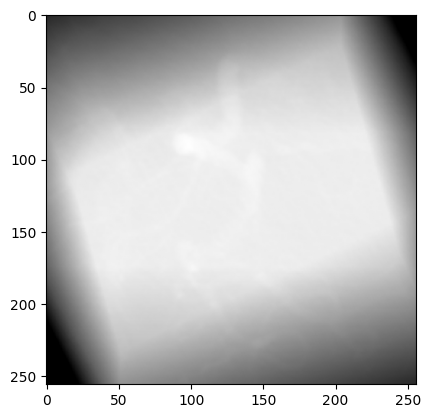

Label: 4


In [14]:
train, label = next(iter(train_dataloader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {label.size()}")
img = train[31].squeeze()
label = label[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

### Model

In [6]:
device = torch.device("cuda")
model = mf.Block().to(device)

summary(model, torch.Size([1,256,256]), 64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [64, 4, 256, 256]              40
       BatchNorm2d-2          [64, 4, 256, 256]               8
         MaxPool2d-3          [64, 4, 128, 128]               0
            Conv2d-4         [64, 16, 128, 128]             592
       BatchNorm2d-5         [64, 16, 128, 128]              32
         MaxPool2d-6           [64, 16, 64, 64]               0
           Flatten-7                [64, 65536]               0
            Linear-8                   [64, 64]       4,194,368
              ReLU-9                   [64, 64]               0
           Linear-10                    [64, 5]             325
Total params: 4,195,365
Trainable params: 4,195,365
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 16.00
Forward/backward pass size (MB): 608.06
Params size (MB): 16.00
Est

In [10]:
output = model(train.to(device))
output

tensor([[ 6.1985e-01,  2.3955e-02,  3.0212e-02,  4.8400e-01,  1.8476e-01],
        [ 6.5117e-01,  1.4886e-01,  1.2441e-01,  3.6171e-01,  2.0682e-01],
        [ 4.7845e-01,  1.3607e-01,  5.5176e-02,  2.7489e-01,  6.9830e-02],
        [ 5.3627e-01,  2.5347e-01,  7.0415e-02,  4.5779e-01,  2.3270e-01],
        [ 4.3612e-01,  8.4752e-02,  5.2255e-02,  1.8342e-01,  1.1921e-01],
        [ 2.7589e-01, -7.7013e-02,  1.8835e-02,  1.5396e-01, -2.1125e-02],
        [ 4.3274e-01,  2.1286e-01,  4.0845e-02,  3.3165e-01, -1.6591e-01],
        [ 5.4490e-01,  2.7851e-01,  5.7468e-02,  3.4628e-01,  2.1422e-02],
        [ 3.2758e-01,  2.0046e-01,  1.6032e-02,  7.7888e-02,  1.0204e-01],
        [ 2.5807e-01,  2.4746e-01,  1.0556e-01, -6.1713e-02, -1.4488e-01],
        [ 6.1379e-01,  3.2520e-01,  9.7173e-02,  2.9315e-01,  2.1032e-01],
        [ 2.3578e-01,  3.7790e-01,  6.0140e-04,  1.8071e-01, -1.4010e-03],
        [ 4.9842e-01, -2.5660e-02, -6.0802e-03,  1.9160e-01,  1.1200e-01],
        [ 5.1873e-01,  3.

### Loss function

In [11]:
loss_fn = nn.CrossEntropyLoss()
loss_fn.to(device=device)

CrossEntropyLoss()

### Optimizer

In [14]:
optimizer = torch.optim.SGD(model.parameters(), lr=params["learning_rate"], momentum=params["momentum"])


### Training

In [17]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_dataloader):
        # Every data instance is an input + label pair
        inputs, labels = data
        

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs.to(device))

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels.to(device))
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_dataloader) + i + 1
            running_loss = 0.

    return last_loss

In [21]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0






EPOCHS = 100

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_dataloader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device))
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
    run["train/loss"].append(avg_loss)
    run["val/loss"].append(avg_vloss)



    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1
model.train(False)
run.stop()

EPOCH 1:
  batch 10 loss: 1.5614964246749878
  batch 20 loss: 1.567820942401886
  batch 30 loss: 1.5873061060905456
  batch 40 loss: 1.5792813897132874
  batch 50 loss: 1.5915108799934388
  batch 60 loss: 1.58370441198349
  batch 70 loss: 1.5867566108703612
  batch 80 loss: 1.5904636621475219
LOSS train 1.5904636621475219 valid 1.5700918436050415
EPOCH 2:
  batch 10 loss: 1.5778284192085266
  batch 20 loss: 1.5563686847686768
  batch 30 loss: 1.5553500413894654
  batch 40 loss: 1.5785451173782348
  batch 50 loss: 1.5605957984924317
  batch 60 loss: 1.5698983311653136
  batch 70 loss: 1.577684211730957
  batch 80 loss: 1.581681001186371
LOSS train 1.581681001186371 valid 1.5633940696716309
EPOCH 3:
  batch 10 loss: 1.5702591776847838
  batch 20 loss: 1.55582195520401
  batch 30 loss: 1.5645249605178833
  batch 40 loss: 1.5682893753051759
  batch 50 loss: 1.5735402822494506
  batch 60 loss: 1.5777566075325011
  batch 70 loss: 1.5794719099998473
  batch 80 loss: 1.5666179060935974
LOSS tr

In [22]:
torch.save(model.state_dict(), "mymodel_classified.pth")

In [23]:
torch.cuda.empty_cache()
del model
del loss_fn

print(torch.cuda.memory_allocated())
print(torch.cuda.memory_reserved())

453302272
480247808
